<a href="https://colab.research.google.com/github/AnjinkLaCoding/ClassificationThenClustering-Method/blob/main/FinalCodingDataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TRAIN_PATH = "obesity_train.csv"
TEST_PATH = "obesity_test.csv"
TARGET_COL = "NObeyesdad"
REQUIRED_NUMERIC_COLS = ["Height", "Weight"]

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"Training data must include the target column {TARGET_COL!r}.")

required_features = set(REQUIRED_NUMERIC_COLS)
missing_train_cols = sorted(required_features.difference(train_df.columns))
missing_test_cols = sorted(required_features.difference(test_df.columns))
if missing_train_cols:
    raise ValueError(f"Training data is missing required column(s): {missing_train_cols}")
if missing_test_cols:
    raise ValueError(f"Test data is missing required column(s): {missing_test_cols}")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
display(train_df.head())

Train shape: (1193, 17)
Test shape:  (918, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,23.000000,Female,1.644161,84.340406,no,yes,2.177243,3.000000,no,no,2.715572,yes,2.230109,0.070897,Sometimes,Public_Transportation,Obesity_Type_I
1,22.000000,Male,1.650000,80.000000,no,no,2.000000,3.000000,no,no,2.000000,yes,3.000000,2.000000,Sometimes,Walking,Overweight_Level_II
2,20.670975,Female,1.509408,64.852953,no,no,2.294067,3.209508,no,no,2.000000,yes,1.103088,1.261043,Sometimes,Public_Transportation,Overweight_Level_II
3,23.000000,Male,1.706525,90.500055,no,yes,2.000000,3.000000,no,no,1.530493,yes,0.967627,1.000000,Sometimes,Public_Transportation,Obesity_Type_I
4,27.000000,Male,1.800000,87.000000,Frequently,no,3.000000,3.000000,no,no,2.000000,no,2.000000,0.000000,Sometimes,Walking,Overweight_Level_I


In [4]:
def summarize_dataframe(df, name):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False),
    })
    print(f"{name} shape: {df.shape}")
    display(summary)

summarize_dataframe(train_df, "Train")
summarize_dataframe(test_df, "Test")

Train shape: (1193, 17)


,dtype,missing,missing_pct,unique
Age,float64,0,0.0,711
Gender,str,0,0.0,2
Height,float64,0,0.0,794
Weight,float64,0,0.0,744
CALC,str,0,0.0,3
FAVC,str,0,0.0,2
FCVC,float64,0,0.0,462
NCP,float64,0,0.0,410
SCC,str,0,0.0,2
SMOKE,str,0,0.0,2


Test shape: (918, 17)


,dtype,missing,missing_pct,unique
Age,float64,0,0.0,712
Gender,str,0,0.0,2
Height,float64,0,0.0,818
Weight,float64,0,0.0,821
CALC,str,0,0.0,4
FAVC,str,0,0.0,2
FCVC,float64,0,0.0,360
NCP,float64,0,0.0,231
SCC,str,0,0.0,2
SMOKE,str,0,0.0,2


What is the unknown class?

In [5]:
UnknownClass = list(set(test_df['NObeyesdad'].unique()).difference(set(train_df['NObeyesdad'].unique())))
print(UnknownClass)

['Obesity_Type_III', 'Obesity_Type_II']


We decided to add BMI to the dataframe as obesity level usually determined by ones BMI.

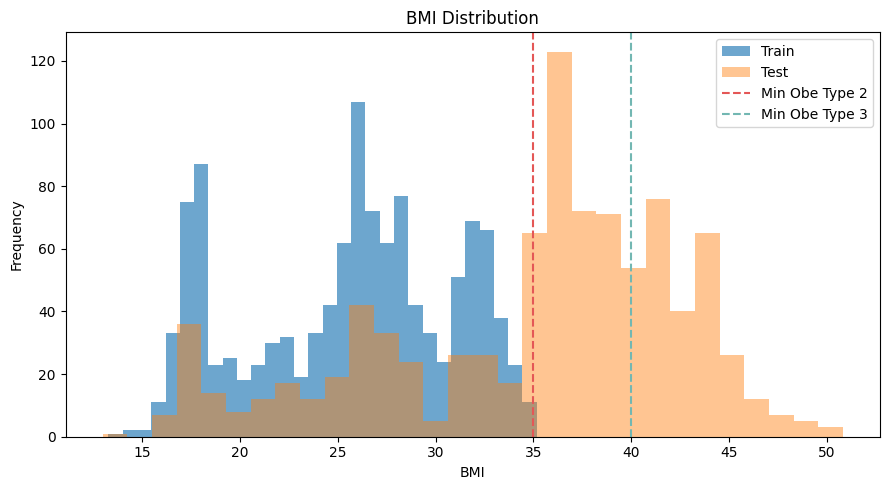

,count,mean,std,min,25%,50%,75%,max
Height,1193.0,1.692144,0.094298,1.450000,1.620000,1.700000,1.760000,1.975663
Weight,1193.0,73.541252,17.641924,39.000000,59.243506,75.093569,85.000000,121.657979
BMI,1193.0,25.577377,5.294804,13.291588,21.303949,26.214876,29.429311,35.171095


In [6]:
def compute_bmi(df):
    height = pd.to_numeric(df["Height"], errors="coerce")
    weight = pd.to_numeric(df["Weight"], errors="coerce")
    return weight / (height ** 2)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["BMI"] = compute_bmi(train_df)
test_df["BMI"] = compute_bmi(test_df)

fig, ax = plt.subplots(figsize=(9, 5))
train_df["BMI"].plot(kind="hist", bins=30, alpha=0.65, ax=ax, label="Train")
test_df["BMI"].plot(kind="hist", bins=30, alpha=0.45, ax=ax, label="Test")
ax.axvline(35, color="#e45756", linestyle="--", label="Min Obe Type 2") #Minimun BMI for obesity type 2
ax.axvline(40, color="#72b7b2", linestyle="--", label="Min Obe Type 3") #Minimum BMI for obesity type 3
ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()
plt.tight_layout()
plt.show()

display(train_df[["Height", "Weight", "BMI"]].describe().T)

In [7]:
print(train_df.head())

         Age  Gender    Height     Weight        CALC FAVC      FCVC  \
0  23.000000  Female  1.644161  84.340406          no  yes  2.177243   
1  22.000000    Male  1.650000  80.000000          no   no  2.000000   
2  20.670975  Female  1.509408  64.852953          no   no  2.294067   
3  23.000000    Male  1.706525  90.500055          no  yes  2.000000   
4  27.000000    Male  1.800000  87.000000  Frequently   no  3.000000   

        NCP SCC SMOKE      CH2O family_history_with_overweight       FAF  \
0  3.000000  no    no  2.715572                            yes  2.230109   
1  3.000000  no    no  2.000000                            yes  3.000000   
2  3.209508  no    no  2.000000                            yes  1.103088   
3  3.000000  no    no  1.530493                            yes  0.967627   
4  3.000000  no    no  2.000000                             no  2.000000   

        TUE       CAEC                 MTRANS           NObeyesdad        BMI  
0  0.070897  Sometimes  Public

Preprocessing

In [8]:
#To split the features and target column
def split_features(df, target_col=TARGET_COL):
    if target_col not in df.columns:
        return df.copy(), None
    return df.drop(columns=[target_col]).copy(), df[target_col].copy()

#To check if both train and test data have the same columns
def align_feature(train_features, test_features):
    missing_in_test = sorted(set(train_features.columns).difference(test_features.columns))
    extra_in_test = sorted(set(test_features.columns).difference(train_features.columns))
    if missing_in_test:
        raise ValueError(f"Test data is missing model feature column(s): {missing_in_test}")
    if extra_in_test:
        print(f"Ignoring extra test column(s) not used by the model: {extra_in_test}")
    return test_features.loc[:, train_features.columns].copy()

#Preparing our dataset for the xgboost
def prepare_xgb_features(df, category_levels=None):
    prepared = df.copy()
    category_cols = prepared.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [col for col in prepared.columns if col not in category_cols]

    #numerical columns stay numerical
    for col in numeric_cols:
        prepared[col] = pd.to_numeric(prepared[col], errors="coerce")

    #Category level is used to store the unique value of each columns
    #The columns name as the key, and the unique value as the value to the dictionary
    #Example: {"color": ["blue", "green", "red"]}
    #When encounter unknown category (unique value), that value will automatically turn into N/A
    if category_levels is None:
        category_levels = {}
        for col in category_cols:
            prepared[col] = prepared[col].astype("category")
            category_levels[col] = prepared[col].cat.categories
    else:
        for col, levels in category_levels.items():
            if col in prepared.columns:
                prepared[col] = pd.Categorical(prepared[col], categories=levels)

    return prepared, category_levels


X_all_raw, y_all_labels = split_features(train_df)
X_test_raw, y_test_labels = split_features(test_df)
X_test_raw = align_feature(X_all_raw, X_test_raw)

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_all_labels)
class_names = label_encoder.classes_
print("Model features:", list(X_all_raw.columns))
print("Classes:", list(class_names))

Model features: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI']
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Overweight_Level_I', 'Overweight_Level_II']


Build model

In [9]:
def build_model():
    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        tree_method="hist",
        eval_metric="mlogloss",
        verbosity=0,
        random_state=RANDOM_STATE,
    )

Stratified Validation

/tmp/ipykernel_16912/2648596091.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = prepared.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
/tmp/ipykernel_16912/2648596091.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-str

,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,XGBoost,0.9874,0.9869,0.9874,0.987,0.9871


XGBoost validation report
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        44
      Normal_Weight       0.98      0.98      0.98        46
     Obesity_Type_I       1.00      1.00      1.00        56
 Overweight_Level_I       1.00      0.96      0.98        47
Overweight_Level_II       0.98      1.00      0.99        46

           accuracy                           0.99       239
          macro avg       0.99      0.99      0.99       239
       weighted avg       0.99      0.99      0.99       239



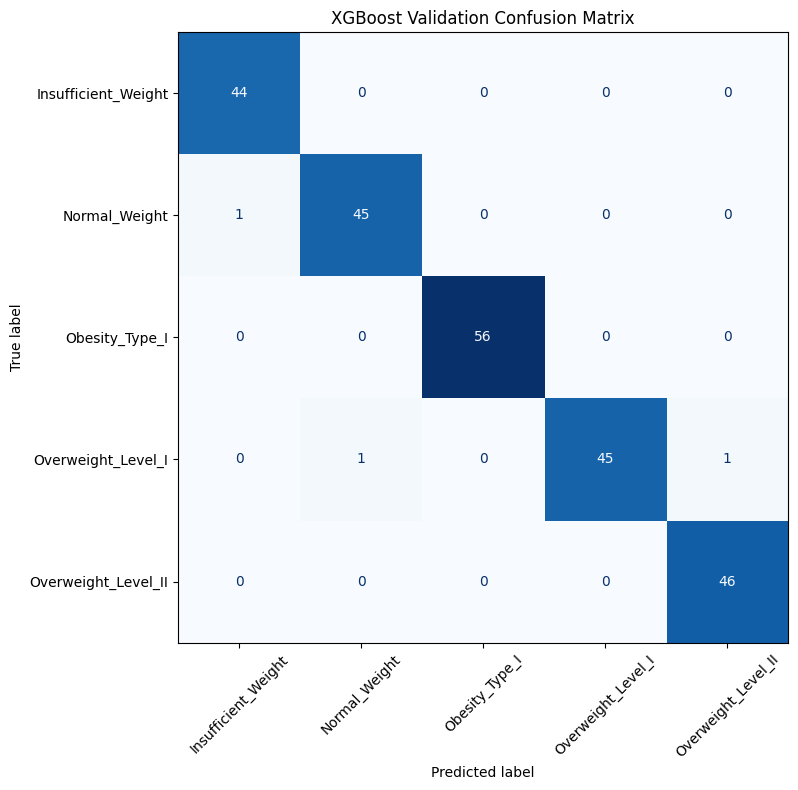

In [10]:
#avoiding a lopsided split — for example, without it,
#a rare class with only a few samples could end up entirely in the training set
#and be absent from validation, making evaluation unreliable.
def stratified_validation_split(X, y, test_size=0.2):
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        raise ValueError("At least two target classes are required for classification.")
    if class_counts.min() < 2:
        raise ValueError(
            "Stratified validation requires at least two rows in every class. "
            f"Class counts: {class_counts.to_dict()}"
        )
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y,
    )

#x_all_raw and y_all is from the train_df
X_train_raw, X_val_raw, y_train, y_val = stratified_validation_split(X_all_raw, y_all)
X_train_xgb, category_levels = prepare_xgb_features(X_train_raw)
X_val_xgb, _ = prepare_xgb_features(X_val_raw, category_levels) #'_' means discarding the value

xgb_val_model = build_model()
xgb_val_model.fit(X_train_xgb, y_train)
xgb_val_proba = xgb_val_model.predict_proba(X_val_xgb)
xgb_val_pred = xgb_val_proba.argmax(axis=1)


validation_scores = pd.DataFrame([
    {
        "model": "XGBoost",
        "accuracy": accuracy_score(y_val, xgb_val_pred),
        "macro_f1": f1_score(y_val, xgb_val_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_val, xgb_val_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_val, xgb_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, xgb_val_pred, average="macro", zero_division=0),
    },
])
display(validation_scores.round(4))

print("XGBoost validation report")
class_indices = np.arange(len(class_names))
print(classification_report(y_val, xgb_val_pred, labels=class_indices, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_val_pred,
    labels=class_indices,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("XGBoost Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
def tune_confidence_threshold(y_true, probabilities, min_coverage=0.60):
    rows = []
    predicted = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    for threshold in np.round(np.arange(0.50, 0.971, 0.01), 2):
        confident = confidence >= threshold
        coverage = confident.mean()
        if confident.any():
            confident_accuracy = accuracy_score(y_true[confident], predicted[confident])
            confident_macro_f1 = f1_score(y_true[confident], predicted[confident], average="macro", zero_division=0)
        else:
            confident_accuracy = np.nan
            confident_macro_f1 = np.nan
        rows.append({
            "threshold": threshold,
            "coverage": coverage,
            "uncertain_rate": 1 - coverage,
            "confident_accuracy": confident_accuracy,
            "confident_macro_f1": confident_macro_f1,
        })

    threshold_df = pd.DataFrame(rows)
    candidates = threshold_df[threshold_df["coverage"] >= min_coverage].dropna()
    if candidates.empty:
        best = threshold_df.dropna().sort_values(
            ["confident_accuracy", "coverage", "threshold"], ascending=[False, False, True]
        ).iloc[0]
    else:
        best = candidates.sort_values(
            ["confident_accuracy", "confident_macro_f1", "coverage", "threshold"],
            ascending=[False, False, False, True],
        ).iloc[0]
    return float(best["threshold"]), threshold_df

confidence_threshold, threshold_table = tune_confidence_threshold(y_val, xgb_val_proba)
print(f"Selected confidence threshold: {confidence_threshold:.2f}")
display(threshold_table.iloc[::5].round(4))

Selected confidence threshold: 0.97


,threshold,coverage,uncertain_rate,confident_accuracy,confident_macro_f1
0,0.50,1.0000,0.0000,0.9874,0.9869
5,0.55,1.0000,0.0000,0.9874,0.9869
10,0.60,1.0000,0.0000,0.9874,0.9869
15,0.65,1.0000,0.0000,0.9874,0.9869
20,0.70,1.0000,0.0000,0.9874,0.9869
25,0.75,1.0000,0.0000,0.9874,0.9869
30,0.80,0.9916,0.0084,0.9873,0.9867
35,0.85,0.9874,0.0126,0.9915,0.9912
40,0.90,0.9833,0.0167,0.9915,0.9911
45,0.95,0.9749,0.0251,0.9914,0.9910


/tmp/ipykernel_16912/2648596091.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = prepared.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
/tmp/ipykernel_16912/2648596091.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-str

Test labels excluded from model evaluation because they were not present in training: ['Obesity_Type_II', 'Obesity_Type_III']
Known-label test accuracy: 0.9630
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.97      0.98      0.97        57
     Obesity_Type_I       1.00      0.99      0.99        70
 Overweight_Level_I       0.95      0.91      0.93        58
Overweight_Level_II       0.92      0.95      0.93        58

           accuracy                           0.96       297
          macro avg       0.96      0.96      0.96       297
       weighted avg       0.96      0.96      0.96       297



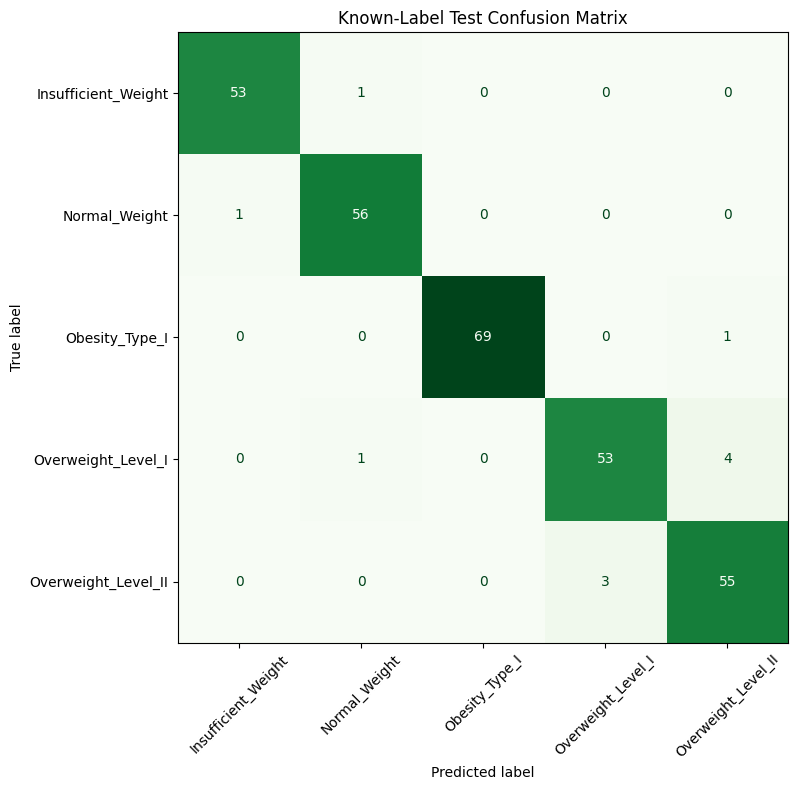

In [12]:
X_all_xgb, final_category_levels = prepare_xgb_features(X_all_raw)
X_test_xgb, _ = prepare_xgb_features(X_test_raw, final_category_levels)

final_model = build_model()
final_model.fit(X_all_xgb, y_all)

test_proba = final_model.predict_proba(X_test_xgb)
test_pred_encoded = test_proba.argmax(axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)
test_confidence = test_proba.max(axis=1)

if y_test_labels is not None:
    known_test_mask = y_test_labels.isin(class_names)
    unknown_test_labels = sorted(set(y_test_labels.dropna().unique()).difference(set(class_names)))
    if unknown_test_labels:
        print("Test labels excluded from model evaluation because they were not present in training:", unknown_test_labels)
    if known_test_mask.any():
        y_test_known = label_encoder.transform(y_test_labels[known_test_mask])
        y_pred_known = test_pred_encoded[known_test_mask.to_numpy()]
        print(f"Known-label test accuracy: {accuracy_score(y_test_known, y_pred_known):.4f}")
        print(classification_report(y_test_known, y_pred_known, labels=class_indices, target_names=class_names, zero_division=0))
        fig, ax = plt.subplots(figsize=(9, 8))
        ConfusionMatrixDisplay.from_predictions(
            y_test_known,
            y_pred_known,
            labels=class_indices,
            display_labels=class_names,
            xticks_rotation=45,
            cmap="Greens",
            ax=ax,
            colorbar=False,
        )
        ax.set_title("Known-Label Test Confusion Matrix")
        plt.tight_layout()
        plt.show()
    else:
        print("No test labels overlap with the training classes, so test metrics were skipped.")
else:
    print("Test labels are not available; generated predictions only.")

Clustering override — constants and shared evaluation helper for relabeling the ceiling rows (test rows predicted as Obesity_Type_I, the highest class seen in training).

In [ ]:
HIGHEST_KNOWN_CLASS = "Obesity_Type_I"
OVERRIDE_CLASS_NAMES = ["Obesity_Type_II", "Obesity_Type_III"]
N_CLUSTERS = 3  # Type_I, Type_II, Type_III

# Full classifier feature set plus BMI (used by clustering stage 1)
CLUSTER_FEATURES = [col for col in X_test_xgb.columns if col != "BMI"] + ["BMI"]
# BMI-dominant subset (used by clustering stage 2) — the I/II/III boundaries are
# clinically defined by BMI alone, so only body-size features enter the geometry
BMI_CLUSTER_FEATURES = ["BMI", "Weight", "Height"]
BMI_WEIGHT = 1.5  # multiplier on the standardized BMI column


def evaluate_full_label_set(final_labels, sources, title):
    """Source summary + accuracy/report/confusion matrix over all 7 classes."""
    source_summary = (
        pd.Series(sources)
        .value_counts()
        .rename_axis("prediction_source")
        .reset_index(name="rows")
    )
    display(source_summary)

    if y_test_labels is None:
        return
    full_label_set = list(dict.fromkeys(list(class_names) + OVERRIDE_CLASS_NAMES))
    labeled_mask = y_test_labels.notna().to_numpy()
    if not labeled_mask.any():
        return
    y_true_full = y_test_labels[labeled_mask].astype(str).to_numpy()
    y_pred_full = np.asarray(final_labels, dtype=object)[labeled_mask]
    print(f"{title} — full-label-set test accuracy: {accuracy_score(y_true_full, y_pred_full):.4f}")
    print(classification_report(
        y_true_full, y_pred_full, labels=full_label_set, zero_division=0
    ))
    fig, ax = plt.subplots(figsize=(9, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_true_full,
        y_pred_full,
        labels=full_label_set,
        display_labels=full_label_set,
        xticks_rotation=45,
        cmap="Oranges",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{title} — Full-Label Confusion Matrix")
    plt.tight_layout()
    plt.show()

**Two-stage clustering override** — stage 1 clusters the ceiling rows with k-means (k=3, full feature set, standardized BMI ×1.5) and keeps only the highest-mean-BMI cluster as **Type III**. Stage 2 re-clusters the remaining rows with k-means (k=2) on **BMI, Weight, Height**; the cluster with the lower mean BMI becomes **Type I**, the other **Type II**.

In [ ]:
def _fit_cluster_matrix(features_df, idx, cluster_features, bmi_weight, n_clusters, random_state=RANDOM_STATE):
    """Build the numeric matrix for rows idx, impute, scale, BMI-weight, and k-means."""
    subset = features_df.iloc[idx]
    matrix = np.zeros((len(idx), len(cluster_features)))
    for i, col in enumerate(cluster_features):
        if col in subset.columns:
            col_data = subset[col]
            if hasattr(col_data, "cat"):
                matrix[:, i] = col_data.cat.codes.to_numpy(dtype=float)
            else:
                matrix[:, i] = pd.to_numeric(col_data, errors="coerce").to_numpy(dtype=float)
    col_means = np.nanmean(matrix, axis=0)
    nan_mask = np.isnan(matrix)
    matrix[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    scaled = StandardScaler().fit_transform(matrix)
    if bmi_weight != 1.0 and "BMI" in cluster_features:
        scaled[:, cluster_features.index("BMI")] *= bmi_weight
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    return kmeans.fit_predict(scaled)


def _print_cluster_mapping(bmi_values, cluster_labels, cluster_to_class):
    print("Cluster -> class mapping (by mean BMI):")
    for c, cls in cluster_to_class.items():
        bmi_c = bmi_values[cluster_labels == c]
        print(
            f"  Cluster {c}: BMI min/mean/max = "
            f"{bmi_c.min():.2f}/{bmi_c.mean():.2f}/{bmi_c.max():.2f} -> {cls}"
        )


def two_stage_cluster_ceiling_rows(
    test_features_xgb,
    test_bmi,
    base_labels,
    confidence,
    threshold,
    stage2_features,
    stage2_bmi_weight=1.0,
    label="",
    random_state=RANDOM_STATE,
):
    """
    Stage 1: k=3 clustering over the ceiling rows, used only to
    peel off the Type III cluster. Stage 2: re-cluster the remaining Type I/II
    rows with k=2; the cluster with the lower mean BMI becomes Type I.
    """
    final_labels = np.array(base_labels, dtype=object)
    sources = np.where(
        confidence >= threshold, "classifier", "classifier_low_confidence"
    ).astype(object)

    ceiling_idx = np.where(final_labels == HIGHEST_KNOWN_CLASS)[0]
    if len(ceiling_idx) < N_CLUSTERS:
        print(
            f"Warning: only {len(ceiling_idx)} ceiling rows found — "
            "skipping clustering override, not enough samples."
        )
        return final_labels, sources

    if label:
        print(f"=== {label} ===")

    # Stage 1 — full-feature geometry (CLUSTER_FEATURES, BMI x BMI_WEIGHT, k=3)
    stage1_clusters = _fit_cluster_matrix(
        test_features_xgb, ceiling_idx, CLUSTER_FEATURES, BMI_WEIGHT, N_CLUSTERS, random_state
    )
    bmi_ceiling = test_bmi.iloc[ceiling_idx].to_numpy()
    cluster_mean_bmi = {c: bmi_ceiling[stage1_clusters == c].mean() for c in range(N_CLUSTERS)}
    sorted_clusters = sorted(cluster_mean_bmi, key=cluster_mean_bmi.get)
    stage1_map = {
        sorted_clusters[0]: "Obesity_Type_I",
        sorted_clusters[1]: "Obesity_Type_II",
        sorted_clusters[2]: "Obesity_Type_III",
    }
    print("Stage 1 (keep Type III only):")
    _print_cluster_mapping(bmi_ceiling, stage1_clusters, stage1_map)

    type3_mask = stage1_clusters == sorted_clusters[2]
    for pos in np.where(type3_mask)[0]:
        final_labels[ceiling_idx[pos]] = "Obesity_Type_III"
        sources[ceiling_idx[pos]] = "clustering_override"

    # Stage 2 — re-cluster the remaining Type I/II rows with k=2
    stage2_idx = ceiling_idx[~type3_mask]
    if len(stage2_idx) < 2:
        print(f"Warning: only {len(stage2_idx)} stage-2 rows — keeping stage-1 labels.")
        return final_labels, sources
    stage2_clusters = _fit_cluster_matrix(
        test_features_xgb, stage2_idx, stage2_features, stage2_bmi_weight, 2, random_state
    )
    bmi_stage2 = test_bmi.iloc[stage2_idx].to_numpy()
    stage2_mean_bmi = {c: bmi_stage2[stage2_clusters == c].mean() for c in range(2)}
    low, high = sorted(stage2_mean_bmi, key=stage2_mean_bmi.get)
    stage2_map = {low: "Obesity_Type_I", high: "Obesity_Type_II"}
    print("Stage 2 (Type I vs Type II):")
    _print_cluster_mapping(bmi_stage2, stage2_clusters, stage2_map)

    for pos, original_idx in enumerate(stage2_idx):
        assigned = stage2_map[stage2_clusters[pos]]
        if assigned != HIGHEST_KNOWN_CLASS:
            final_labels[original_idx] = assigned
            sources[original_idx] = "clustering_override_stage2"

    return final_labels, sources

In [ ]:
final_pred_labels_C, prediction_sources_C = two_stage_cluster_ceiling_rows(
    X_test_xgb,
    test_df["BMI"],
    test_pred_labels,
    test_confidence,
    confidence_threshold,
    stage2_features=BMI_CLUSTER_FEATURES,
    stage2_bmi_weight=1.0,
    label="Two-stage clustering override — stage 2 on BMI/Weight/Height",
)
evaluate_full_label_set(final_pred_labels_C, prediction_sources_C, "Two-stage clustering override")

# Diagnostic: agreement with the clinical BMI rule
# (Type II = BMI 35-40, Type III = BMI >= 40) on the ceiling rows
def clinical_bmi_class(bmi):
    if bmi >= 40:
        return "Obesity_Type_III"
    if bmi >= 35:
        return "Obesity_Type_II"
    return "Obesity_Type_I"

ceiling_mask = np.asarray(test_pred_labels) == HIGHEST_KNOWN_CLASS
clinical_labels = test_df["BMI"][ceiling_mask].apply(clinical_bmi_class).to_numpy()
cluster_assigned = np.asarray(final_pred_labels_C, dtype=object)[ceiling_mask]
agreement = (cluster_assigned == clinical_labels).mean()
print(f"{agreement:.2%} of ceiling rows match the clinical 35/40 BMI rule")

SHAP explainability

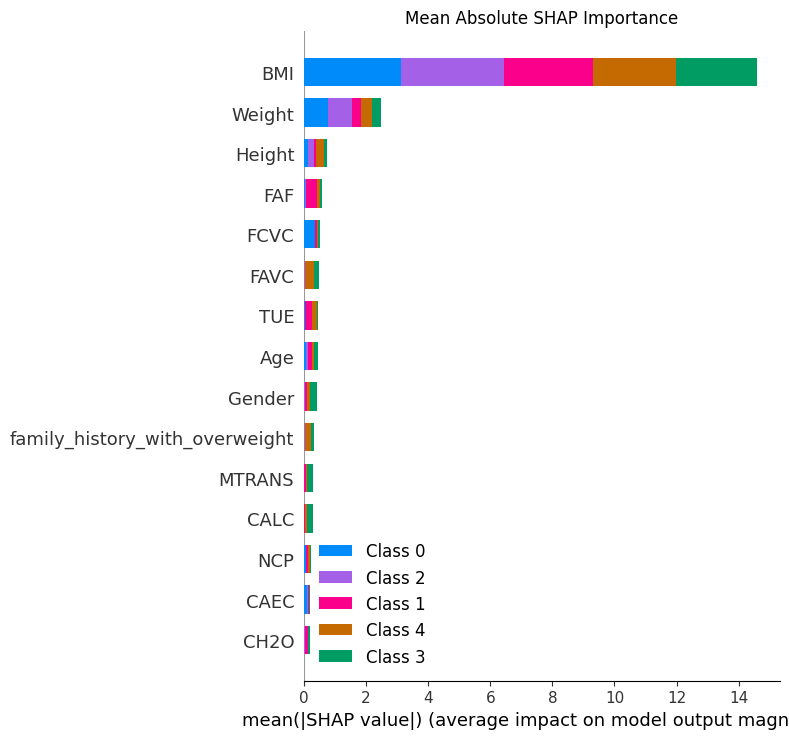

<Figure size 900x600 with 0 Axes>

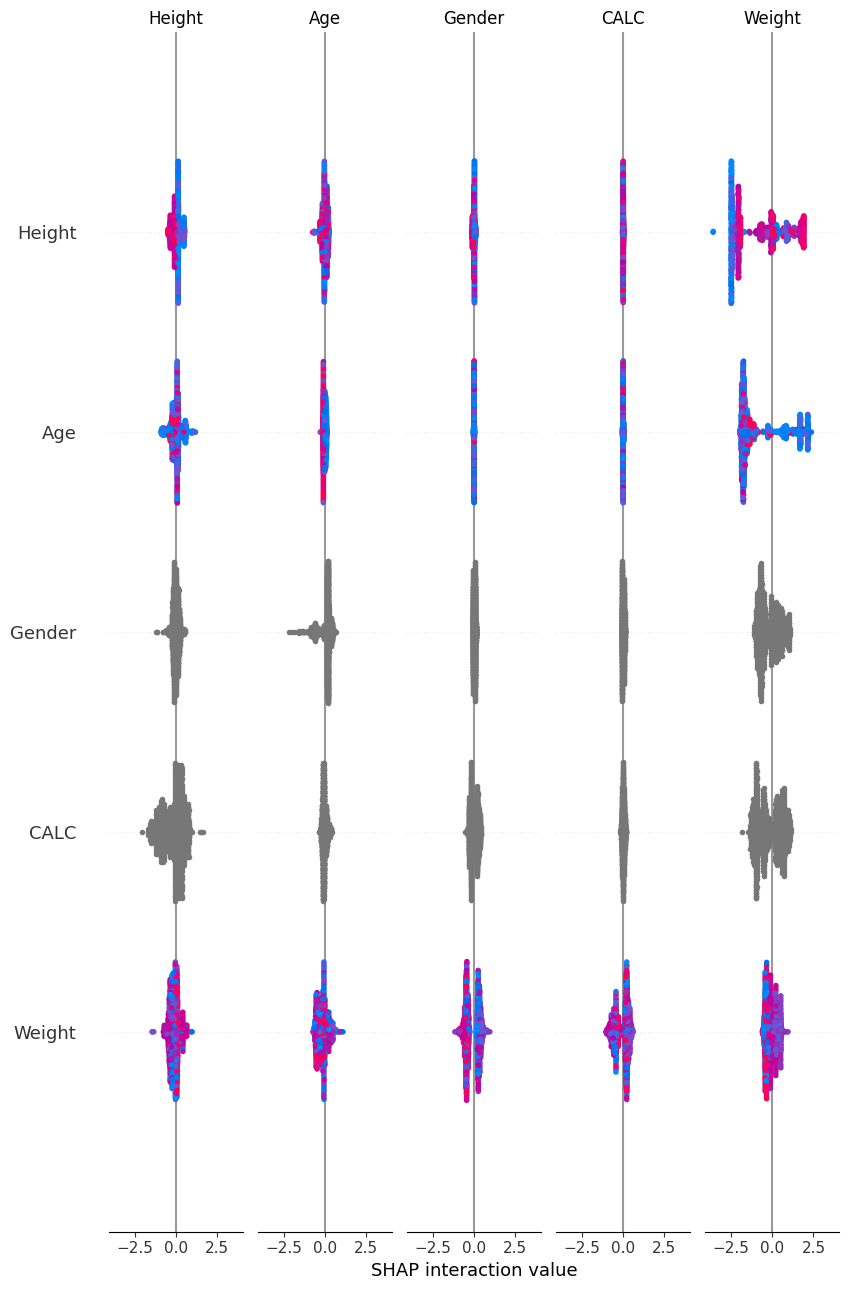

,xgb_importance,mean_abs_shap
BMI,0.43877,2.92045
Weight,0.15036,0.49524
Height,0.05785,0.15063
FAF,0.02407,0.11562
FCVC,0.01953,0.10275
FAVC,0.03225,0.09664
TUE,0.02234,0.09268
Age,0.01898,0.09133
Gender,0.01627,0.08135
family_history_with_overweight,0.03477,0.06187


In [16]:
def mean_abs_shap_by_feature(shap_values, feature_names):
    if isinstance(shap_values, list):
        arr = np.stack(shap_values, axis=-1)
    else:
        arr = np.asarray(shap_values)

    if arr.ndim == 2:
        mean_abs = np.abs(arr).mean(axis=0)
    elif arr.ndim == 3:
        if arr.shape[1] == len(feature_names):
            mean_abs = np.abs(arr).mean(axis=(0, 2))
        elif arr.shape[2] == len(feature_names):
            mean_abs = np.abs(arr).mean(axis=(0, 1))
        else:
            raise ValueError(f"Could not align SHAP array shape {arr.shape} with features.")
    else:
        raise ValueError(f"Unsupported SHAP array shape: {arr.shape}")
    return pd.Series(mean_abs, index=feature_names, name="mean_abs_shap")

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_all_xgb)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_all_xgb, plot_type="bar", show=False, max_display=15)
plt.title("Mean Absolute SHAP Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_all_xgb, show=False, max_display=15)
plt.tight_layout()
plt.show()

xgb_importance = pd.Series(final_model.feature_importances_, index=X_all_xgb.columns, name="xgb_importance")
shap_importance = mean_abs_shap_by_feature(shap_values, X_all_xgb.columns)
importance_comparison = pd.concat([xgb_importance, shap_importance], axis=1).sort_values("mean_abs_shap", ascending=False)
display(importance_comparison.head(15).round(5))

In [ ]:
output_df = test_df.copy()
output_df["BMI"] = test_df["BMI"]
output_df["predicted_label"] = final_pred_labels_C
output_df["prediction_source"] = prediction_sources_C
output_df["confidence"] = test_confidence

probability_df = pd.DataFrame(test_proba, columns=[f"probability_{label}" for label in class_names], index=output_df.index)
output_df = pd.concat([output_df, probability_df], axis=1)

output_df.to_csv("obesity_predictions.csv", index=False)
print(f"Saved docs with {len(output_df)} rows and {len(output_df.columns)} columns.")
display(output_df.head())